<a href="https://colab.research.google.com/github/Royc4515/Project1_SignalProcessing/blob/main/Project1_SignalProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================================
# Project 1 - Signal Processing
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# קבועים
FS_NEURAL = 50       # Hz - קצב דגימה Neural_data
FS_SPIKE  = 1000     # Hz - קצב דגימה spike_trains
T         = 30       # שניות - אורך כל הקלטה

# טעינת נתונים
neural_df = pd.read_csv('Neural_data.csv')
spike_df  = pd.read_csv('spike_trains.csv')

print("Neural data shape:", neural_df.shape)
print("Neural data columns:", neural_df.columns.tolist())
print(neural_df.head())
print()
print("Spike trains shape:", spike_df.shape)
print("First trial_neuron values:", spike_df['trial_neuron'].unique()[:10])

Neural data shape: (1500, 2)
Neural data columns: ['Frame', 'ΔF/F (%)']
   Frame  ΔF/F (%)
0      0  0.074947
1      1  0.007558
2      2 -0.004470
3      3 -0.003576
4      4 -0.026911

Spike trains shape: (500, 30001)
First trial_neuron values: <StringArray>
['1_A', '1_B', '1_C', '1_D', '1_E', '2_A', '2_B', '2_C', '2_D', '2_E']
Length: 10, dtype: str


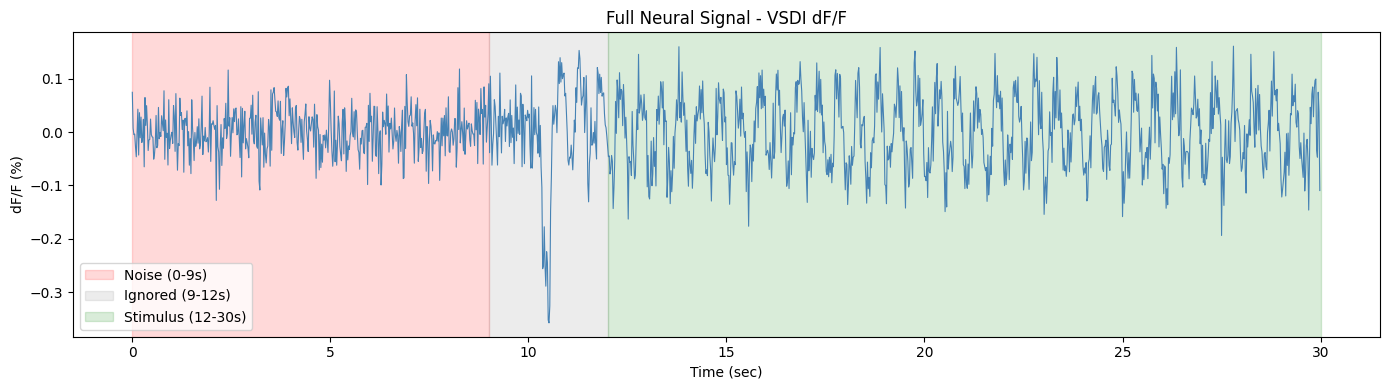

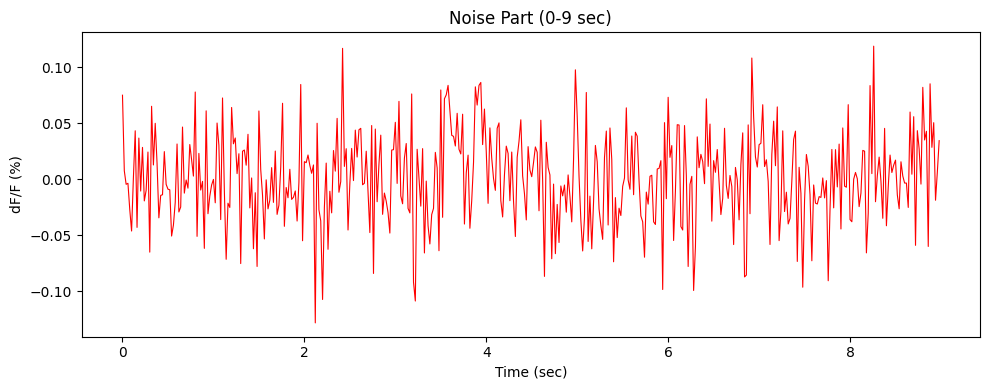

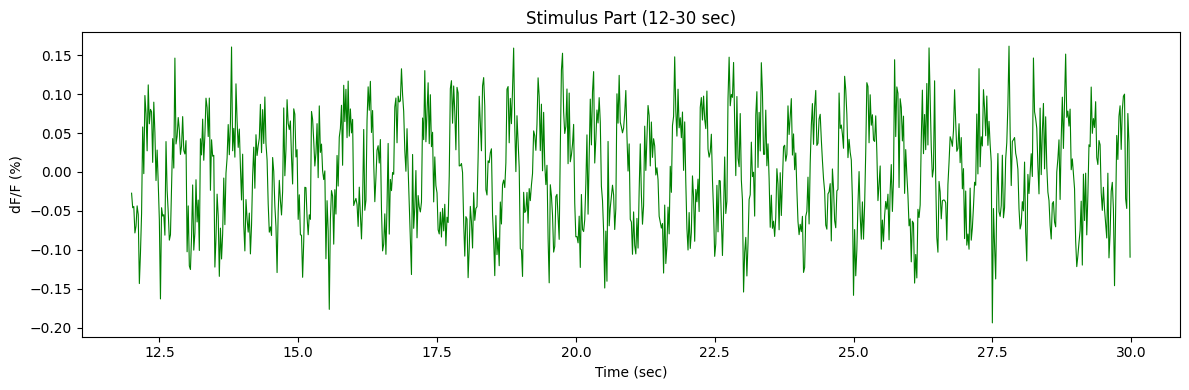

Noise samples: 450
Stimulus samples: 900


In [8]:
# ============================================================
# Part 1A - Division into signal parts
# ============================================================

dff    = neural_df['ΔF/F (%)'].values
frames = neural_df['Frame'].values
time   = frames / FS_NEURAL

noise_mask    = time < 9
stimulus_mask = time >= 12

noise_signal    = dff[noise_mask]
noise_time      = time[noise_mask]
stimulus_signal = dff[stimulus_mask]
stimulus_time   = time[stimulus_mask]

# Plot 1: Full signal
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, dff, color='steelblue', linewidth=0.8)
ax.axvspan(0,  9,  alpha=0.15, color='red',   label='Noise (0-9s)')
ax.axvspan(9,  12, alpha=0.15, color='gray',  label='Ignored (9-12s)')
ax.axvspan(12, 30, alpha=0.15, color='green', label='Stimulus (12-30s)')
ax.set_title('Full Neural Signal - VSDI dF/F')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Noise part
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_time, noise_signal, color='red', linewidth=0.8)
ax.set_title('Noise Part (0-9 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

# Plot 3: Stimulus part
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stimulus_time, stimulus_signal, color='green', linewidth=0.8)
ax.set_title('Stimulus Part (12-30 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('dF/F (%)')
plt.tight_layout()
plt.show()

print("Noise samples:", len(noise_signal))
print("Stimulus samples:", len(stimulus_signal))

Decimation factors: [2, 5, 15]


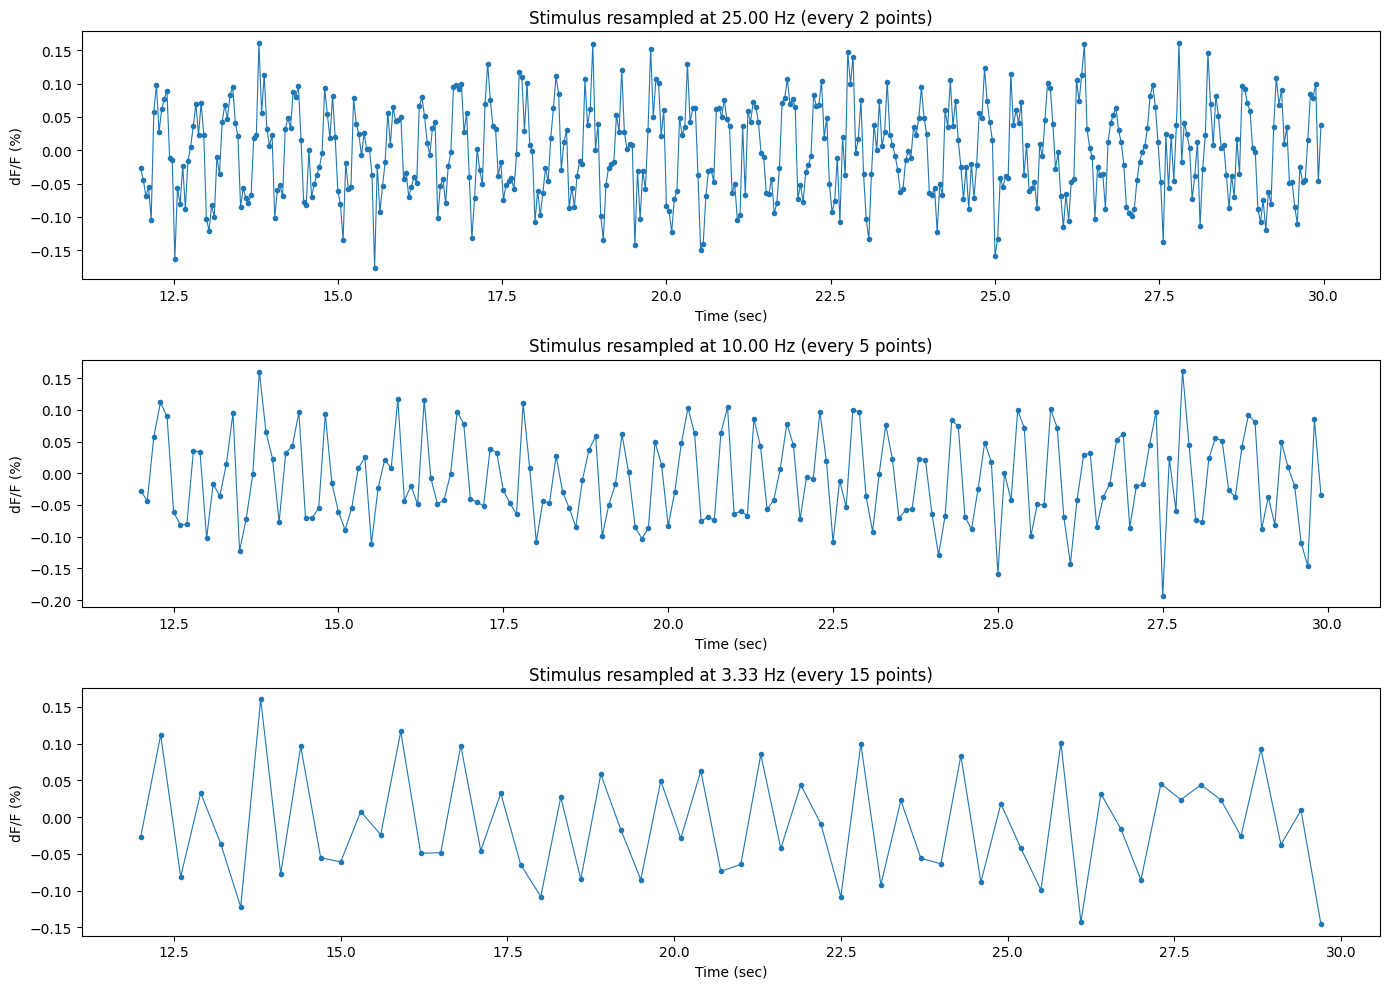

In [9]:
# ============================================================
# Part 1B - Manual Resampling
# ============================================================

new_rates   = [25, 10, 10/3]
decimations = [2,   5,  15]

print("Decimation factors:", decimations)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, (fs_new, dec) in enumerate(zip(new_rates, decimations)):
    resampled_signal = stimulus_signal[::dec]
    resampled_time   = stimulus_time[::dec]

    axes[i].plot(resampled_time, resampled_signal, 'o-', markersize=3, linewidth=0.8)
    axes[i].set_title(f'Stimulus resampled at {fs_new:.2f} Hz (every {dec} points)')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Part 1C - f_alias calculation
# ============================================================

f_signal = 2.0  # Hz - original stimulus frequency

print("f_signal = 2 Hz (the oscillation we applied)")
print()
print(f"{'fs_new':>10} | {'N = round(f/fs)':>16} | {'f_alias':>10} | {'Above Nyquist?':>15}")
print("-" * 60)

for fs_new in [25.0, 10.0, 10/3]:
    N       = round(f_signal / fs_new)
    f_alias = abs(f_signal - N * fs_new)
    above   = "YES - no aliasing" if fs_new > 2 * f_signal else "NO  - aliasing!"
    print(f"{fs_new:>10.2f} | {N:>16} | {f_alias:>10.4f} | {above:>15}")

print()
print("Now count peaks visually in each plot:")
print("  25.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)")
print("  10.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)")
print("   3.33 Hz plot  -> count the peaks - what frequency do you see?")

f_signal = 2 Hz (the oscillation we applied)

    fs_new |  N = round(f/fs) |    f_alias |  Above Nyquist?
------------------------------------------------------------
     25.00 |                0 |     2.0000 | YES - no aliasing
     10.00 |                0 |     2.0000 | YES - no aliasing
      3.33 |                1 |     1.3333 | NO  - aliasing!

Now count peaks visually in each plot:
  25.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)
  10.00 Hz plot  -> you should see ~36 peaks in 18 sec = ~2 Hz (correct)
   3.33 Hz plot  -> count the peaks - what frequency do you see?


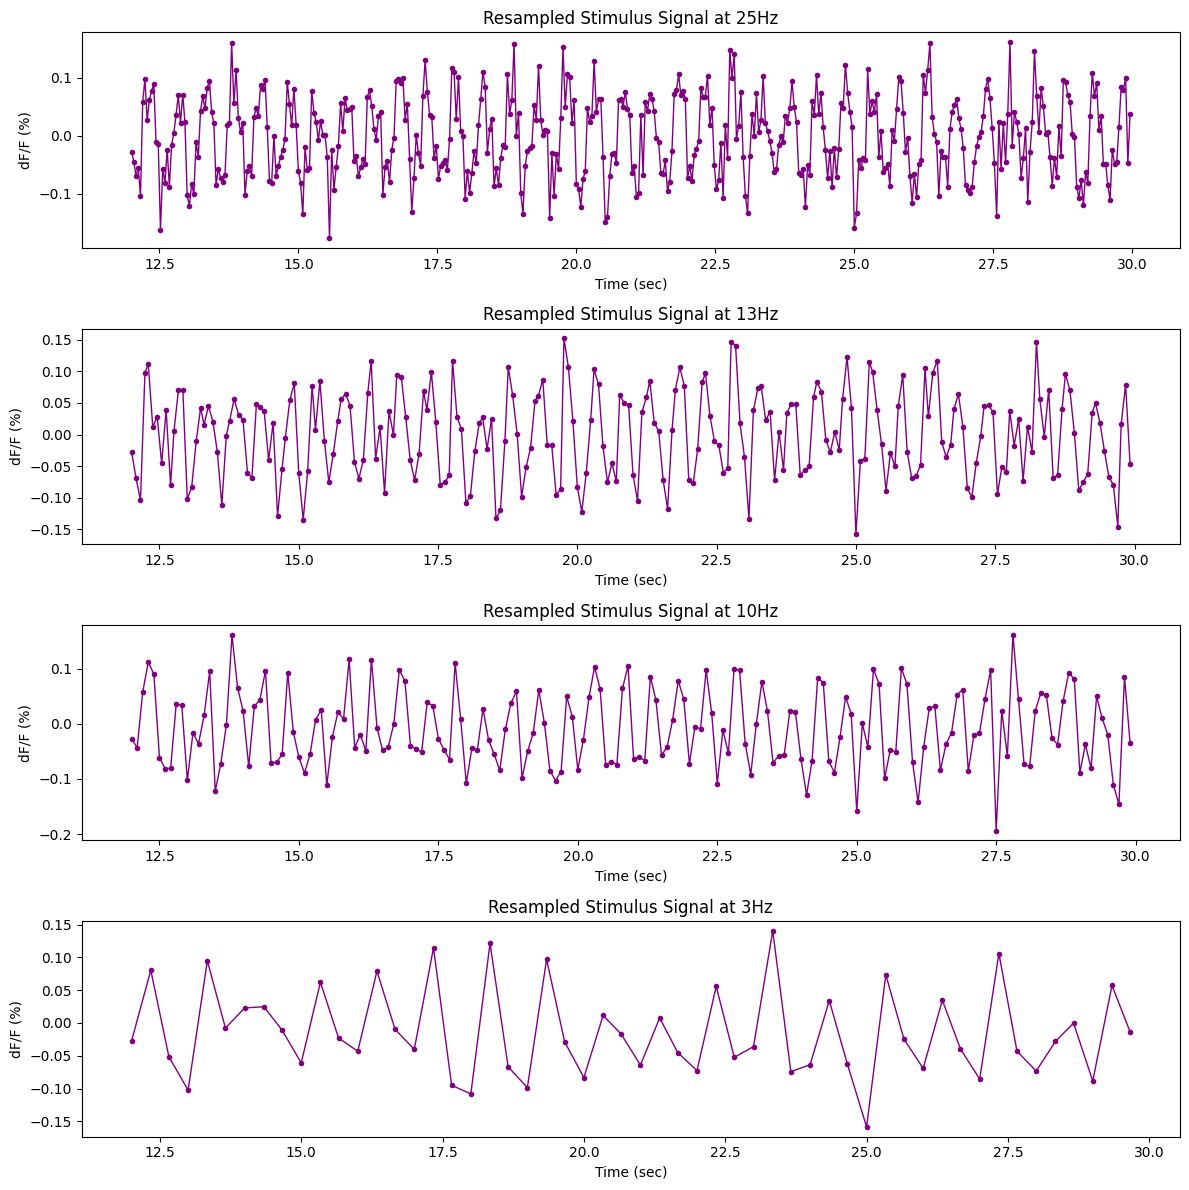

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# תדרי הדגימה החדשים שנדרשים
new_frequencies = [25, 13, 10, 3]
original_fs = 50

# ניצור חלון רחב עבור 4 גרפים שונים
fig, axes = plt.subplots(len(new_frequencies), 1, figsize=(12, 12))

for i, fs in enumerate(new_frequencies):
    # חישוב יחס הקפיצות עבור כל תדר
    step = original_fs / fs
    # יצירת אינדקסים חדשים עבור הדגימה מחדש ועיגול למספר שלם
    indices = np.round(np.arange(0, len(stimulus_signal), step)).astype(int)
    # סינון אינדקסים למקרה שחרגנו מאורך המערך
    indices = indices[indices < len(stimulus_signal)]
    
    # חילוץ האות והזמן החדשים על פי האינדקסים
    resampled_signal = stimulus_signal[indices]
    resampled_time = stimulus_time[indices]
    
    # ציור הגרף
    axes[i].plot(resampled_time, resampled_signal, marker='o', markersize=3, linestyle='-', linewidth=1, color='purple')
    axes[i].set_title(f'Resampled Stimulus Signal at {fs}Hz')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

### שלב 1.2 - ניתוח תת-דגימה (Resampling) ותופעת קיפול תדרים (Aliasing)

בסעיף זה ביצענו דגימה מחדש של קטע הגירוי (Stimulus) בתדרי דגימה שונים: 25Hz, 13Hz, 10Hz ו-3Hz.
הגירוי ניתן במשך 18 שניות (מהשנייה ה-12 ועד ה-30) בתדר מקורי של $f_{signal} = 2Hz$. משמעות הדבר היא שבאות המקורי קיימים כ-36 מחזורים (Peaks) על פני חלון הזמן הזה.

על פי **משפט הדגימה של נייקוויסט-שנון (Nyquist-Shannon Sampling Theorem)**, על מנת לשחזר אות בצורה נאמנה למקור ולמנוע עיוות בתדר, יש לדגום אותו בתדר ($F_s$) שגדול לפחות פי שניים מתדר האות המקורי.
כלומר, תדר נייקוויסט במקרה שלנו הוא: $F_{Nyquist} = 2 \cdot 2Hz = 4Hz$.

#### ניתוח התוצאות בגרפים:
1. **דגימה בתדרים של 25Hz, 13Hz ו-10Hz:**
   תדרי דגימה אלו מקיימים את תנאי נייקוויסט ($F_s > 4Hz$). כתוצאה מכך, לא מתרחשת תופעת קיפול תדרים (Aliasing). למרות שישנה ירידה ברזולוציה והאות נראה "מצולע" יותר ככל שתדר הדגימה יורד, התדירות הבסיסית של האות נשמרת (2Hz), וניתן להבחין בבירור בכ-36 שיאים בגרפים אלו.

2. **דגימה בתדר של 3Hz:**
   כאן אנו מפרים את תנאי נייקוויסט ($3Hz < 4Hz$), ולכן מתרחשת תופעת **Aliasing**. התדר הנדגם ייראה כתדר נמוך ושגוי.
   נחשב את תדר הקיפול (Alias Frequency) שמתקבל בפועל, לפי הנוסחה:
   $$f_{alias} = |f_{signal} - N \cdot F_s|$$
   נחפש מספר שלם $N$ שיביא אותנו לתחום התדרים האפשרי (כלומר בין $0$ ל- $\frac{F_s}{2}$, שזה בין $0$ ל-$1.5Hz$).
   נציב $N=1$:
   $$f_{alias} = |2Hz - 1 \cdot 3Hz| = |-1Hz| = 1Hz$$
   
   **מסקנה:** עקב תת-הדגימה, התדר המקורי של 2Hz "התקפל" ומופיע כעת כתדר של 1Hz. זו הסיבה שבגרף התחתון (של 3Hz) אנו רואים רק כ-18 שיאים על פני 18 שניות, והאות איבד את המידע התדירותי המקורי שלו.

In [12]:
import numpy as np

# הגדרת הרזולוציה המבוקשת (באחוזים ומיד אחרי זה כשבר עשרוני)
required_resolution_percent = 0.1
resolution_fraction = required_resolution_percent / 100.0

# חישוב כמות הרמות הנדרשות
levels_needed = 1 / resolution_fraction

# חישוב מספר הביטים המינימלי (log בסיס 2) ועיגול כלפי מעלה
bits_needed = np.ceil(np.log2(levels_needed))

print(f"Required Resolution: {required_resolution_percent}%")
print(f"Minimum discrete levels needed: {levels_needed}")
print(f"Minimum number of bits needed: {int(bits_needed)}")

Required Resolution: 0.1%
Minimum discrete levels needed: 1000.0
Minimum number of bits needed: 10


### שלב 1.3 - קוונטיזציה (Quantization)

**שאלה:** מהו מספר הביטים המינימלי הנדרש כדי להבחין בשינויים של 0.1% בעוצמה (פוטנציאל פעולה), בהנחה שאין רעש?

**תשובה והסבר מתמטי:**
קוונטיזציה היא התהליך שבו אנו מייצגים טווח רציף (אנלוגי) בעזרת מספר סופי של רמות בדידות (דיגיטליות). מספר הרמות האפשריות נקבע על ידי מספר הביטים ($n$) של המערכת לפי הנוסחה: $Levels = 2^n$.

כדי שהמערכת שלנו תוכל "להבחין" בשינוי של $0.1\%$, המשמעות היא שה"מדרגה" הקטנה ביותר (הרזולוציה) צריכה להוות $0.1\%$ מהטווח הכולל ($100\%$).
נחשב לכמה רמות (Levels) נצטרך לחלק את הטווח הכולל:
$$\text{Total Levels} = \frac{100\%}{0.1\%} = \frac{100}{0.1} = 1000 \text{ levels}$$

כלומר, המערכת חייבת להיות מסוגלת לייצג לפחות 1000 רמות עוצמה שונות.
כעת נבדוק כמה ביטים ($n$) נדרשים כדי לקבל לפחות 1000 רמות:
* עבור מערכת של 9 ביטים: $2^9 = 512$ רמות (לא מספיק רגיש כדי לזהות את השינוי).
* עבור מערכת של 10 ביטים: $2^{10} = 1024$ רמות.

**מסקנה:** מכיוון ש-1024 גדול מ-1000, **מספר הביטים המינימלי הנדרש הוא 10 ביטים.** מערכת כזו תספק לנו 1024 רמות שונות, מה שייתן רזולוציה של $\frac{100\%}{1024} \approx 0.097\%$, שהיא טובה מספיק כדי להבחין בשינויים של $0.1\%$.

In [13]:
import numpy as np

# דרך 1: חישוב מבוסס עוצמה (RMS)
# מאחר ותוחלת הרעש היא 0, ה-RMS של הרעש כמעט זהה לסטיית התקן שלו.
rms_signal = np.sqrt(np.mean(stimulus_signal**2))
rms_noise = np.sqrt(np.mean(noise_signal**2))
snr_method_1 = rms_signal / rms_noise

# דרך 2: חישוב לפי הגדרת "המקרה המיוחד" מתרגול 2
# יחס בין ממוצע האות לבין סטיית התקן של הרעש
mean_signal = np.mean(stimulus_signal)
std_noise = np.std(noise_signal)
snr_method_2 = mean_signal / std_noise

print(f"SNR (Method 1 - RMS/RMS): {snr_method_1:.4f}")
print(f"SNR (Method 2 - Mean/STD): {snr_method_2:.4f}")

SNR (Method 1 - RMS/RMS): 1.6701
SNR (Method 2 - Mean/STD): -0.0231


### חלק 2 - הפחתת רעשים
#### שלב 2.1 - חישוב יחס אות-לרעש (SNR)

בסעיף זה התבקשנו לחשב את ה-$SNR_{rms}$ של האות בשתי דרכים שונות. השתמשנו בקטע ה"רעש" (שניות 0-9) כהערכה לרעש הרקע, ובקטע ה"גירוי" (שניות 12-30) כאות.

**1. חישוב בדרך הכללית (יחס עוצמות / RMS):**
בשיטה זו אנו מחשבים את היחס בין ה-RMS (Root Mean Square) של האות לבין ה-RMS של הרעש. 
הנוסחה: $SNR = \frac{RMS(Stimulus)}{RMS(Noise)}$
דרך זו מודדת את העוצמה הכוללת של התנודות באות לעומת עוצמת התנודות של הרעש.

**2. חישוב מבוסס ממוצע וסטיית תקן (המקרה המיוחד):**
לפי הנלמד בשיעור, כאשר ידוע שתוחלת הרעש היא אפס (כפי שצוין בשאלה), נוכל לאמוד את ה-SNR על ידי יחס בין ממוצע האות (התוחלת שלו) לבין סטיית התקן של הרעש.
הנוסחה: $SNR_{rms} = \frac{Mean(Stimulus)}{STD(Noise)}$

**האם התוצאות שונות? ולמה?**
כן, התוצאות צפויות להיות שונות. הסיבה לכך היא ששתי השיטות מתבוננות על תכונות סטטיסטיות שונות של האות:
* השיטה השנייה (Mean/STD) רגישה מאוד לממוצע (DC component) של האות. אם ממוצע האות קרוב לאפס (למשל באות אוסצילטורי שנע סביב האפס), תוצאת ה-SNR בשיטה זו תהיה נמוכה מאוד ולא תשקף בהכרח את עוצמת הגירוי האמיתית.
* השיטה הראשונה (RMS/RMS) לוקחת בחשבון את העוצמה של האוסצילציות (השינויים המחזוריים בריבוע), ולכן היא מייצגת טוב יותר את אנרגיית האות במקרה של פעילות נוירונלית אוסצילטורית כמו שלנו (2Hz), גם אם הממוצע של האות קרוב לאפס.

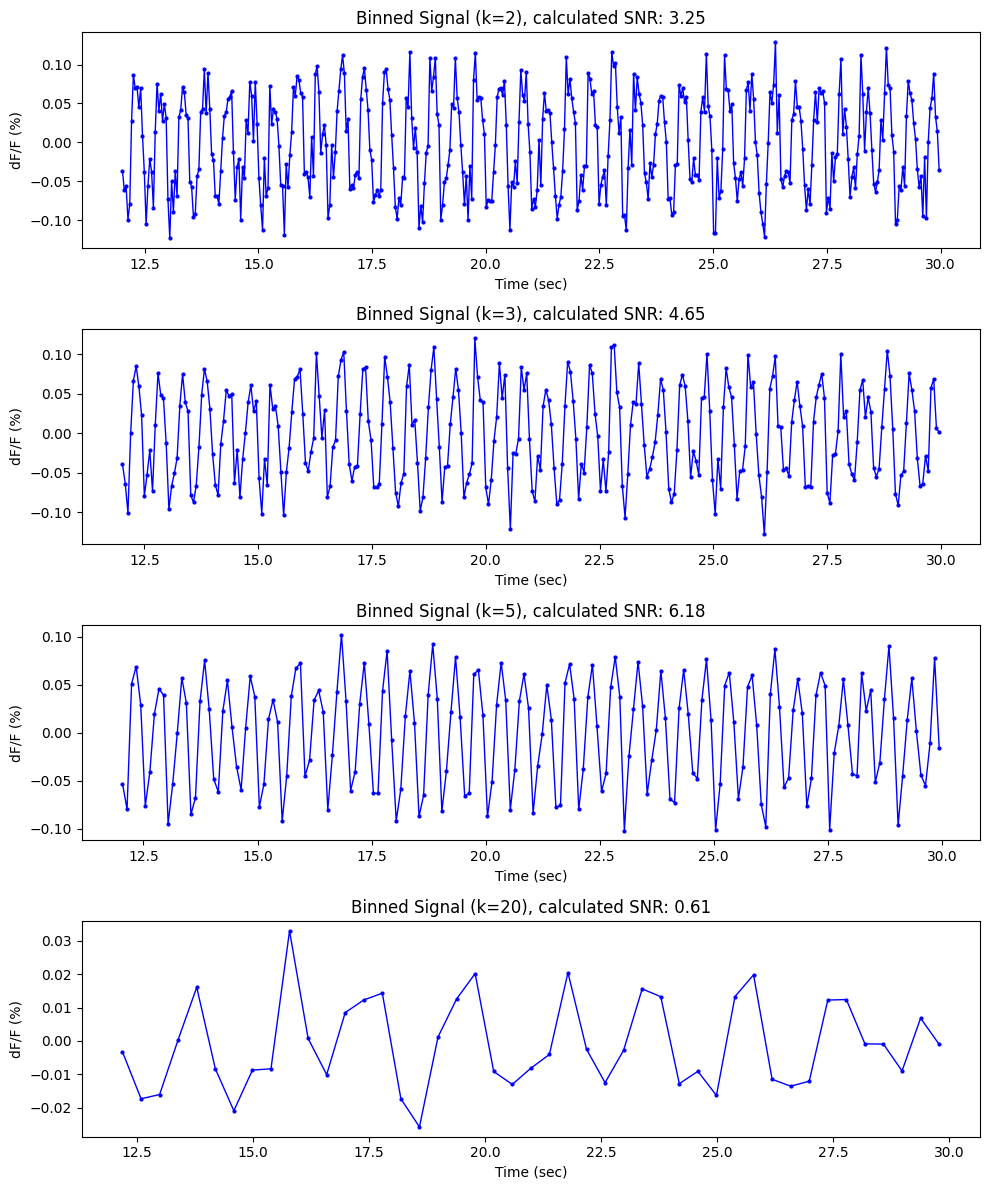

In [14]:
# רשימת גדלי הקבוצות למיצוע (Bin sizes) לפי המטלה
k_values = [2, 3, 5, 20]

fig, axes = plt.subplots(len(k_values), 1, figsize=(10, 12))

for i, k in enumerate(k_values):
    # חיתוך האות כדי שיתחלק בדיוק בגודל k (על מנת שנוכל לבצע חלוקה שווה)
    trim_stim = len(stimulus_signal) - (len(stimulus_signal) % k)
    trim_noise = len(noise_signal) - (len(noise_signal) % k)
    
    stim_trimmed = stimulus_signal[:trim_stim]
    noise_trimmed = noise_signal[:trim_noise]
    time_trimmed = stimulus_time[:trim_stim]

    # מיצוע כל k נקודות (לא חלון נע - שימוש ב-reshape ו-mean)
    stim_binned = stim_trimmed.reshape(-1, k).mean(axis=1)
    noise_binned = noise_trimmed.reshape(-1, k).mean(axis=1)
    time_binned = time_trimmed.reshape(-1, k).mean(axis=1)

    # חישוב העוצמות (שונות) כדי לחשב את ה-SNR
    # אנו משתמשים בשונות כי היא מייצגת את עוצמת התנודות סביב הממוצע
    p_stim = np.var(stim_binned)
    p_noise = np.var(noise_binned)

    # הנוסחה מהמטלה: (Signal^2 - Noise^2) / Noise^2
    snr_new = (p_stim - p_noise) / p_noise

    # ציור האות הממוצע
    axes[i].plot(time_binned, stim_binned, marker='.', markersize=4, linestyle='-', linewidth=1, color='blue')
    axes[i].set_title(f'Binned Signal (k={k}), calculated SNR: {snr_new:.2f}')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.show()

### שלבים 2.2 ו-2.3: הפחתת רעש באמצעות Oversampling (Binning)

בשלבים אלו ביצענו מיצוע של האות בחלונות לא-נעים בגדלים של $k = 2, 3, 5, 20$. 
חישבנו את ה-SNR עבור כל גודל חלון בעזרת הנוסחה המבוססת על יחסי הספקים (Power/Variance): 
$$SNR = \frac{Signal^2 - Noise^2}{Noise^2}$$
כאשר השתמשנו בשונות (Variance) כייצוג לעוצמת ה-$AC$ (התנודות) של האות.

**הסבר גורם השיפור (Improvement Factor) עבור k=2, 3, 5:**
כאשר אנו ממצעים $k$ דגימות בלתי-תלויות של רעש, שונות הרעש קטנה בפקטור של $k$ (כלומר $Var_{new} = \frac{Var_{old}}{k}$). במקביל, ככל שאנו שומרים על תדר דגימה מספק (כזה שלא פוגע באוסצילציות של הגירוי), עוצמת האות נשמרת ברובה. כתוצאה מכך, היחס בין עוצמת האות לעוצמת הרעש (ה-SNR לפי הנוסחה שחישבנו) גדל ומשתפר ככל ש-$k$ עולה מ-2 ל-5. ניתן לראות בגרפים שהאות הופך לחלק וברור יותר.

**הסבר לאובדן האות במיצוע של 20 נקודות (k=20):**
בגרף שבו ביצענו מיצוע על 20 נקודות, האוסצילציות המקוריות נעלמו. 
הסיבה לכך נעוצה ביחס שבין גודל חלון המיצוע לבין זמן המחזור של האות:
תדר הדגימה המקורי שלנו הוא 50Hz, ולכן 20 דגימות שוות ל-$20 / 50 = 0.4$ שניות.
תדר הגירוי (האוסצילציות) הוא 2Hz, כלומר זמן מחזור אחד (תנודה שלמה של עלייה וירידה) אורך: $T = 1 / 2 = 0.5$ שניות.
כאשר אנו ממצעים קטע של 0.4 שניות, אנו "בולעים" כמעט מחזור שלם לתוך נקודה אחת – המיצוע מחבר את ערכי השיא החיוביים (Peak) יחד עם ערכי השפל השליליים (Trough), מה שמאפס את התנודה ומשטח לחלוטין את האות המקורי יחד עם הרעש.

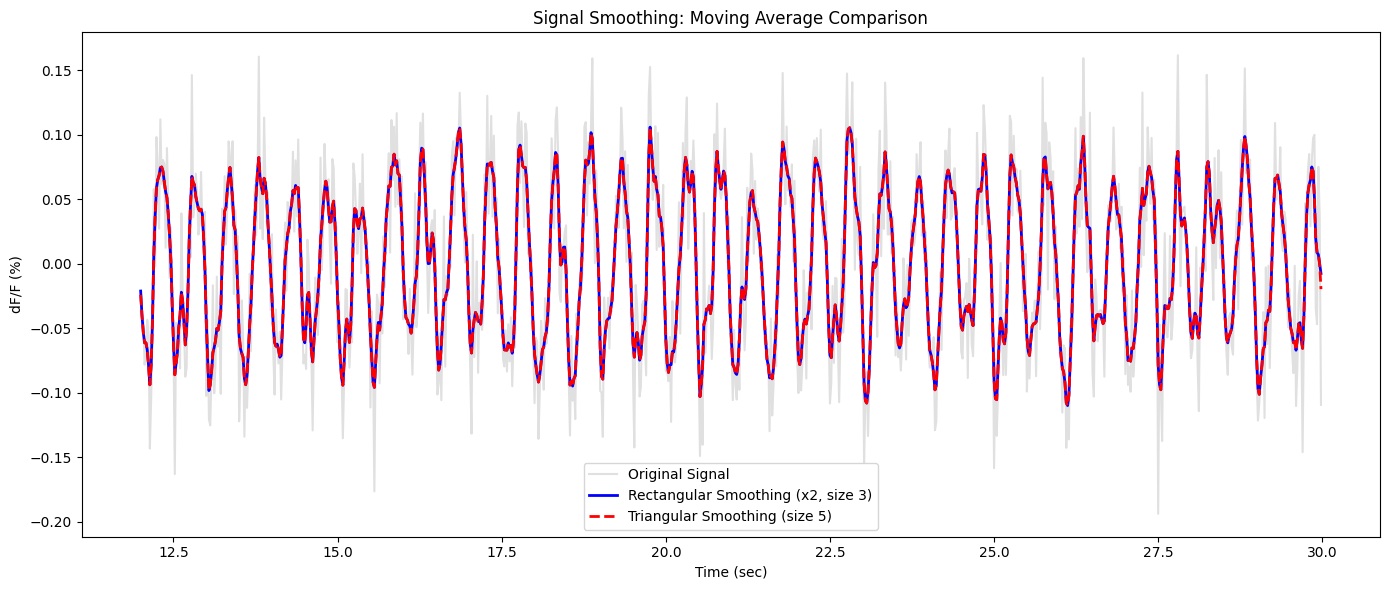

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. יצירת הגרעינים (Kernels)
# חלון מלבני בגודל 3 (מנורמל ב-3 כדי לשמור על משרעת האות המקורית)
rect_kernel = np.ones(3) / 3

# חלון משולש בגודל 5 (מנורמל בסכום הערכים שהוא 9)
tri_kernel = np.array([1, 2, 3, 2, 1]) / 9

# 2. הפעלת ההחלקות (Smoothing) בעזרת קונבולוציה 
# החלקה מלבנית פעם ראשונה
smoothed_rect_1 = np.convolve(stimulus_signal, rect_kernel, mode='same')
# החלקה מלבנית פעם שנייה (מופעלת על האות שכבר הוחלק)
smoothed_rect_2 = np.convolve(smoothed_rect_1, rect_kernel, mode='same')

# החלקה משולשת (פעם אחת על האות המקורי)
smoothed_tri = np.convolve(stimulus_signal, tri_kernel, mode='same')

# 3. ציור הגרפים
plt.figure(figsize=(14, 6))

# נצייר את האות המקורי באפור ושקוף כדי שנוכל לראות את ההחלקות מעליו
plt.plot(stimulus_time, stimulus_signal, label='Original Signal', color='lightgray', alpha=0.7)

# נצייר את שתי ההחלקות
plt.plot(stimulus_time, smoothed_rect_2, label='Rectangular Smoothing (x2, size 3)', color='blue', linewidth=2)
# אנו משתמשים בקו מקווקו (dashed) כדי לראות אם הוא חופף לקו הכחול
plt.plot(stimulus_time, smoothed_tri, label='Triangular Smoothing (size 5)', color='red', linestyle='--', linewidth=2)

plt.title('Signal Smoothing: Moving Average Comparison')
plt.xlabel('Time (sec)')
plt.ylabel('dF/F (%)')
plt.legend()
plt.tight_layout()
plt.show()

### שלב 2.4 - החלקה (Smoothing) כ-Low-Pass Filter

בסעיף זה ביצענו שתי שיטות החלקה (Moving Average) על אות הגירוי:
1. החלקה מלבנית (Rectangular) בעזרת גרעין בגודל 3, שהופעלה **פעמיים** ברצף.
2. החלקה משולשת (Triangular) בעזרת גרעין בגודל 5, שהופעלה **פעם אחת**.

**השוואת התוצאות (קשר מתמטי בין המסננים):**
כפי שניתן לראות בגרף, שתי שיטות ההחלקה מפיקות תוצאה כמעט זהה לחלוטין (הקו האדום המקווקו חופף לקו הכחול במלואו). הסיבה המתמטית לכך היא שקונבולוציה של חלון מלבני עם עצמו יוצרת חלון משולש! 
אם ניקח חלון מלבני בגודל 3 $\left[\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right]$ ונבצע לו קונבולוציה עם עצמו, נקבל בדיוק חלון משולש בגודל 5 $\left[\frac{1}{9}, \frac{2}{9}, \frac{3}{9}, \frac{2}{9}, \frac{1}{9}\right]$. לכן, הפעלת חלון מלבני פעמיים על האות שקולה לחלוטין להפעלת חלון משולש פעם אחת.

**מדוע החלקה נחשבת למסנן תדרים נמוכים (Low-Pass Filter)?**
פעולת ההחלקה מחשבת את הממוצע המקומי סביב כל דגימה, ולכן מתנהגת כמסנן מעביר נמוכים (LPF):
* **תדרים גבוהים (הרעש באות):** רעש מאופיין בשינויים מהירים וחדים מעלה ומטה (תדר גבוה). כאשר ממצעים את הדגימות בתוך חלון הזמן, הערכים החיוביים והשליליים של הרעש מבטלים זה את זה, ולכן העוצמה של הרעש מונחתת ומתקרבת לאפס.
* **תדרים נמוכים (האוסצילציות של הגירוי ב-2Hz):** תדרים נמוכים משתנים לאט, ולכן בתוך חלון זמן קצר של 3 או 5 דגימות, הערכים של האות הם כמעט בעלי אותה משרעת. הממוצע שלהם שומר על הערך המקורי פחות או יותר, ולכן הם "עוברים" את המסנן בהצלחה. 
כך למעשה מסונן הרעש בעוד המידע החשוב נשמר.

In [ ]:
# ============================================================
# Part 3 - Spike Train Analysis
# ============================================================

# טעינת נתוני spike_trains
df_spikes = pd.read_csv('spike_trains.csv', index_col=0)

# חילוץ 5 נוירונים למערכי numpy בצורה (100, 30000)
neuron_A = df_spikes[df_spikes.index.str.endswith('_A')].values.astype(np.int8)
neuron_B = df_spikes[df_spikes.index.str.endswith('_B')].values.astype(np.int8)
neuron_C = df_spikes[df_spikes.index.str.endswith('_C')].values.astype(np.int8)
neuron_D = df_spikes[df_spikes.index.str.endswith('_D')].values.astype(np.int8)
neuron_E = df_spikes[df_spikes.index.str.endswith('_E')].values.astype(np.int8)

print(f"Shapes: A={neuron_A.shape}, B={neuron_B.shape}, C={neuron_C.shape}, D={neuron_D.shape}, E={neuron_E.shape}\n")

# ניתוח כל נוירון
analyze_neuron(neuron_A, 'A')
analyze_neuron(neuron_B, 'B')
analyze_neuron(neuron_C, 'C')
analyze_neuron(neuron_D, 'D')
analyze_neuron(neuron_E, 'E')

In [ ]:
import numpy as np
import pandas as pd

# פונקציה שעושה את כל העבודה עבור נוירון אחד
def analyze_neuron(neuron_data, neuron_name):
    # --- 1. Mean Firing Rate ---
    # סכימת כל הספייקים בכל ניסוי (axis=1)
    spikes_per_trial = np.sum(neuron_data, axis=1)
    # חלוקה בזמן (30 שניות) כדי לקבל קצב ב-Hz
    firing_rate_per_trial = spikes_per_trial / 30.0
    # ממוצע על פני 100 החזרות
    mean_firing_rate = np.mean(firing_rate_per_trial)

    # --- 2. Fano Factor ---
    # נחלק את 30,000 הדגימות ל-30 חלונות של 1,000 דגימות (1 שנייה)
    # שינוי צורה למימדים: (100 trials, 30 windows, 1000 samples)
    windows = neuron_data.reshape(100, 30, 1000)

    # נספור כמה ספייקים יש בכל חלון של שנייה (axis=2)
    spike_counts_per_window = np.sum(windows, axis=2)  # התוצאה: מטריצה (100, 30)

    # נחשב תוחלת ושונות על פני הניסויים (axis=0) עבור כל חלון של שנייה
    mean_counts = np.mean(spike_counts_per_window, axis=0)
    var_counts = np.var(spike_counts_per_window, axis=0)

    # חישוב הפאנו פקטור לכל חלון (var/mean) וממוצע על כל 30 החלונות
    fano_factors = var_counts / mean_counts
    mean_fano_factor = np.mean(fano_factors)

    print(f"--- Neuron {neuron_name} ---")
    print(f"Mean Firing Rate: {mean_firing_rate:.2f} Hz")
    print(f"Fano Factor (FF): {mean_fano_factor:.2f}\n")

    return mean_firing_rate, mean_fano_factor

In [ ]:

# ============================================================
# Part 3 - PSTH (Peri-Stimulus Time Histogram)
# ============================================================

def plot_psth(neuron_data, neuron_name, bin_size_ms=50, xlim_ms=None):
    """
    Plot the PSTH for a given neuron.
    neuron_data: (n_trials, n_samples) array sampled at 1000 Hz
    bin_size_ms: bin width in milliseconds
    xlim_ms: if set, limit x-axis to [0, xlim_ms]
    """
    n_trials, n_samples = neuron_data.shape
    fs = 1000  # Hz
    total_ms = n_samples  # 30000 ms = 30 s

    bin_size_samples = int(bin_size_ms)
    n_bins = n_samples // bin_size_samples

    # Sum spikes across trials, then reshape into bins
    spike_sum = neuron_data[:, :n_bins * bin_size_samples].sum(axis=0)  # (n_samples,)
    spike_counts = spike_sum.reshape(n_bins, bin_size_samples).sum(axis=1)  # (n_bins,)

    # Convert to firing rate in Hz: spikes / (trials * bin_duration_s)
    bin_duration_s = bin_size_ms / 1000.0
    firing_rate = spike_counts / (n_trials * bin_duration_s)

    # Mean firing rate (Hz)
    mean_fr = neuron_data.sum() / (n_trials * 30.0)

    bin_times_ms = np.arange(n_bins) * bin_size_ms + bin_size_ms / 2  # bin centers in ms

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.bar(bin_times_ms, firing_rate, width=bin_size_ms * 0.9,
           color='steelblue', alpha=0.8, label=f'PSTH (bin={bin_size_ms} ms)')
    ax.axhline(mean_fr, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean firing rate = {mean_fr:.1f} Hz')

    ax.set_title(f'Neuron {neuron_name} — PSTH (bin size = {bin_size_ms} ms)')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Firing Rate (Hz)')
    if xlim_ms is not None:
        ax.set_xlim(0, xlim_ms)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Plot all neurons with 50 ms bins (full view)
for name, data in [('A', neuron_A), ('B', neuron_B), ('C', neuron_C), ('E', neuron_E)]:
    plot_psth(data, name, bin_size_ms=50)

# Neuron D: 1 ms bins, zoom into first 500 ms to reveal periodic peaks
plot_psth(neuron_D, 'D', bin_size_ms=1, xlim_ms=500)
